# Alternate Classification Methods

:::{admonition} Learning Objectives
:class: tip

By the end of this chapter, you will be able to:
- Explain the k-nearest neighbors algorithm and identify its hyperparameters
- Describe how the Naive Bayes classifier uses Bayes' theorem and Gaussian assumptions
- Explain how decision trees partition feature space and why they overfit
- Apply all three classifiers with scikit-learn and compare their decision boundaries
- Discuss the trade-offs between these methods in terms of interpretability, speed, and accuracy
:::

In the prior chapters we discussed discriminative generalized linear models in depth
and studied the support vector machine. These methods all share a common structure:
they learn a parametric function — a linear combination of features, possibly
transformed by a link function or kernel — that separates classes in feature space.
Here we introduce three fundamentally different approaches to classification:
k-nearest neighbors (kNN), Naive Bayes, and decision trees. None of these methods
requires optimizing a loss function in the traditional sense, and each has a
distinct set of assumptions, strengths, and failure modes.

A recurring theme in this chapter is the **bias-variance trade-off**. Models with
too few constraints underfit the data (high bias), while models with too much
flexibility memorize noise (high variance). Understanding where each algorithm sits
on this spectrum — and which hyperparameters control it — is essential for practical
model selection.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('../settings/plot_style.mplstyle')

clrs = np.array(['#003057', '#EAAA00', '#4B8B9B', '#B3A369', '#377117',
                 '#1879DB', '#8E8B76', '#F5D580', '#002233'])

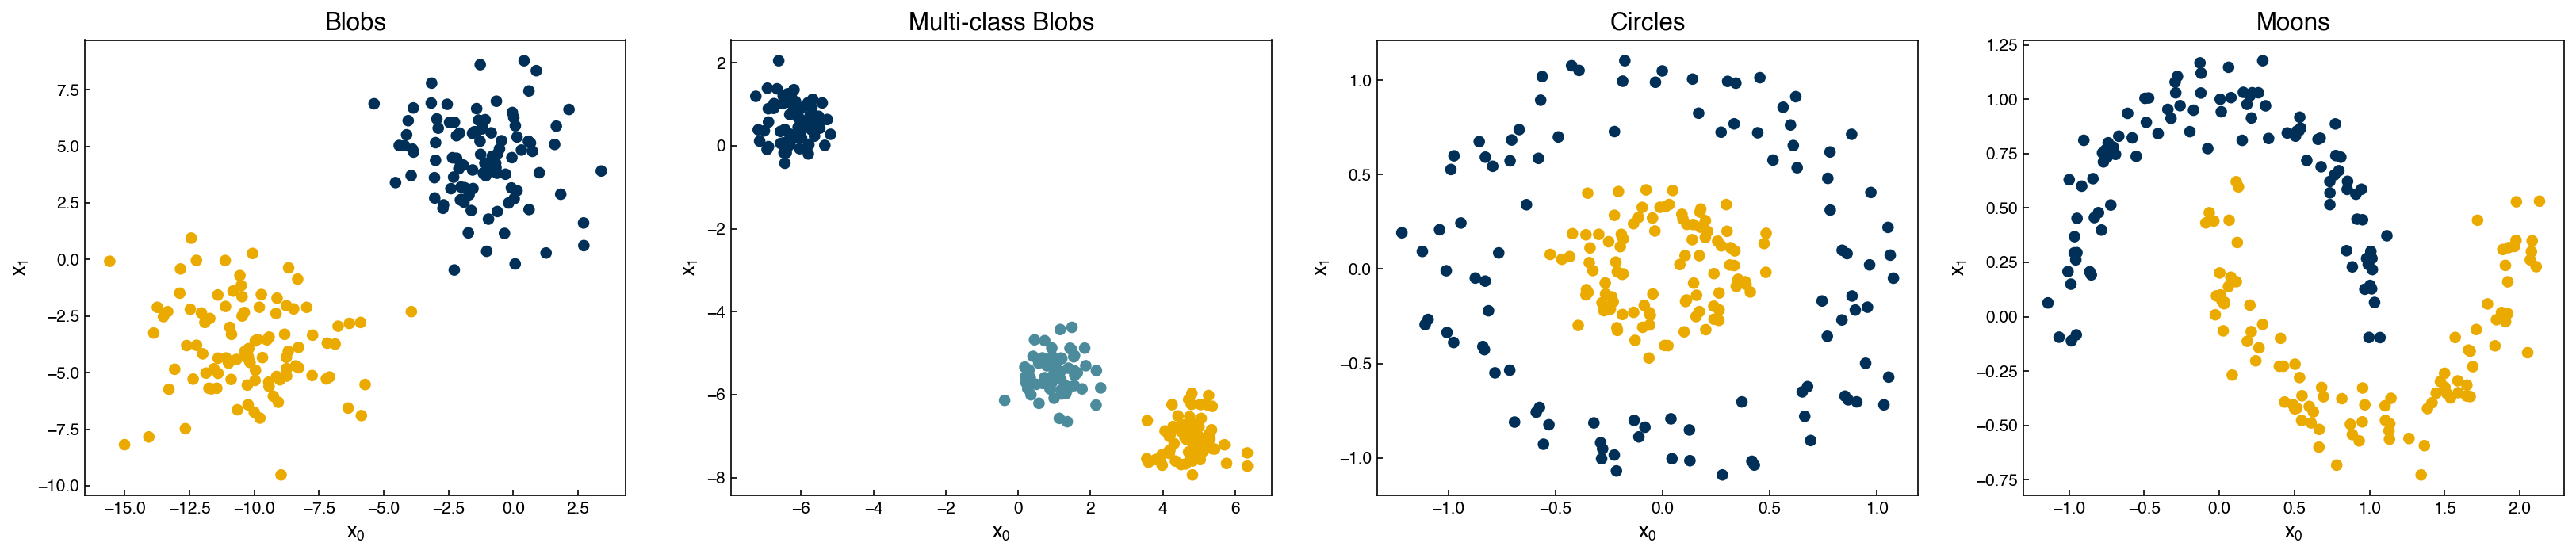

In [2]:
from sklearn.datasets import make_blobs, make_moons, make_circles

np.random.seed(1)
noisiness = 1

X_blob,    y_blob    = make_blobs(n_samples=200, centers=2, cluster_std=2*noisiness, n_features=2)
X_mc,      y_mc      = make_blobs(n_samples=200, centers=3, cluster_std=0.5*noisiness, n_features=2)
X_circles, y_circles = make_circles(n_samples=200, factor=0.3, noise=0.1*noisiness)
X_moons,   y_moons   = make_moons(n_samples=200, noise=0.1*noisiness)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
all_datasets = [(X_blob, y_blob), (X_mc, y_mc), (X_circles, y_circles), (X_moons, y_moons)]
titles = ['Blobs', 'Multi-class Blobs', 'Circles', 'Moons']

for ax, (Xi, yi), title in zip(axes, all_datasets, titles):
    ax.scatter(Xi[:, 0], Xi[:, 1], c=clrs[yi])
    ax.set_xlabel('$x_0$')
    ax.set_ylabel('$x_1$')
    ax.set_title(title)

plt.tight_layout()
plt.show()

## k-Nearest Neighbors

The k-nearest neighbors (kNN) algorithm classifies a new point by **majority vote**:
find the $k$ closest training points and assign the class that wins the plurality.
If there is a tie, $k$ is decremented by 1 until it is broken.

Because boundaries are determined locally by the data rather than by a global function,
kNN can represent highly non-linear decision regions. The flip side is that the
"model" is the entire training set — making prediction slow for large datasets.

### Custom Implementation

We need three building blocks:

1. **Distance metric** — how far apart are two points?
2. **Neighbor lookup** — which $k$ training points are closest?
3. **Class assignment** — what does the neighborhood vote?

In [3]:
def distance(x1, x2):
    return np.linalg.norm(x1 - x2)

def get_neighbor_idxs(x, x_list, k):
    dist_pairs = [(distance(x, xi), i) for i, xi in enumerate(x_list)]
    dist_pairs.sort()
    return [i for _, i in dist_pairs[:k]]

In [4]:
from collections import Counter

def assign_class(x, X_train, y_train, k):
    neighbor_idxs = get_neighbor_idxs(x, X_train, k)
    y_list = list(y_train)
    votes = [y_list[i] for i in neighbor_idxs]
    return Counter(votes).most_common(1)[0][0]

def kNN(X, k, X_train, y_train):
    return np.array([assign_class(xi, X_train, y_train, k) for xi in X])

:::{note}
There is no explicit training step in kNN — calling `fit` simply stores the
training data. The computation happens entirely at prediction time, which is
why kNN is called a **lazy learner**. The hyperparameters are the number of
neighbors $k$ and the choice of distance metric (Euclidean by default).
:::

### Demonstration: kNN on Toy Datasets

Let's first predict on the full moons dataset, training on all the data:

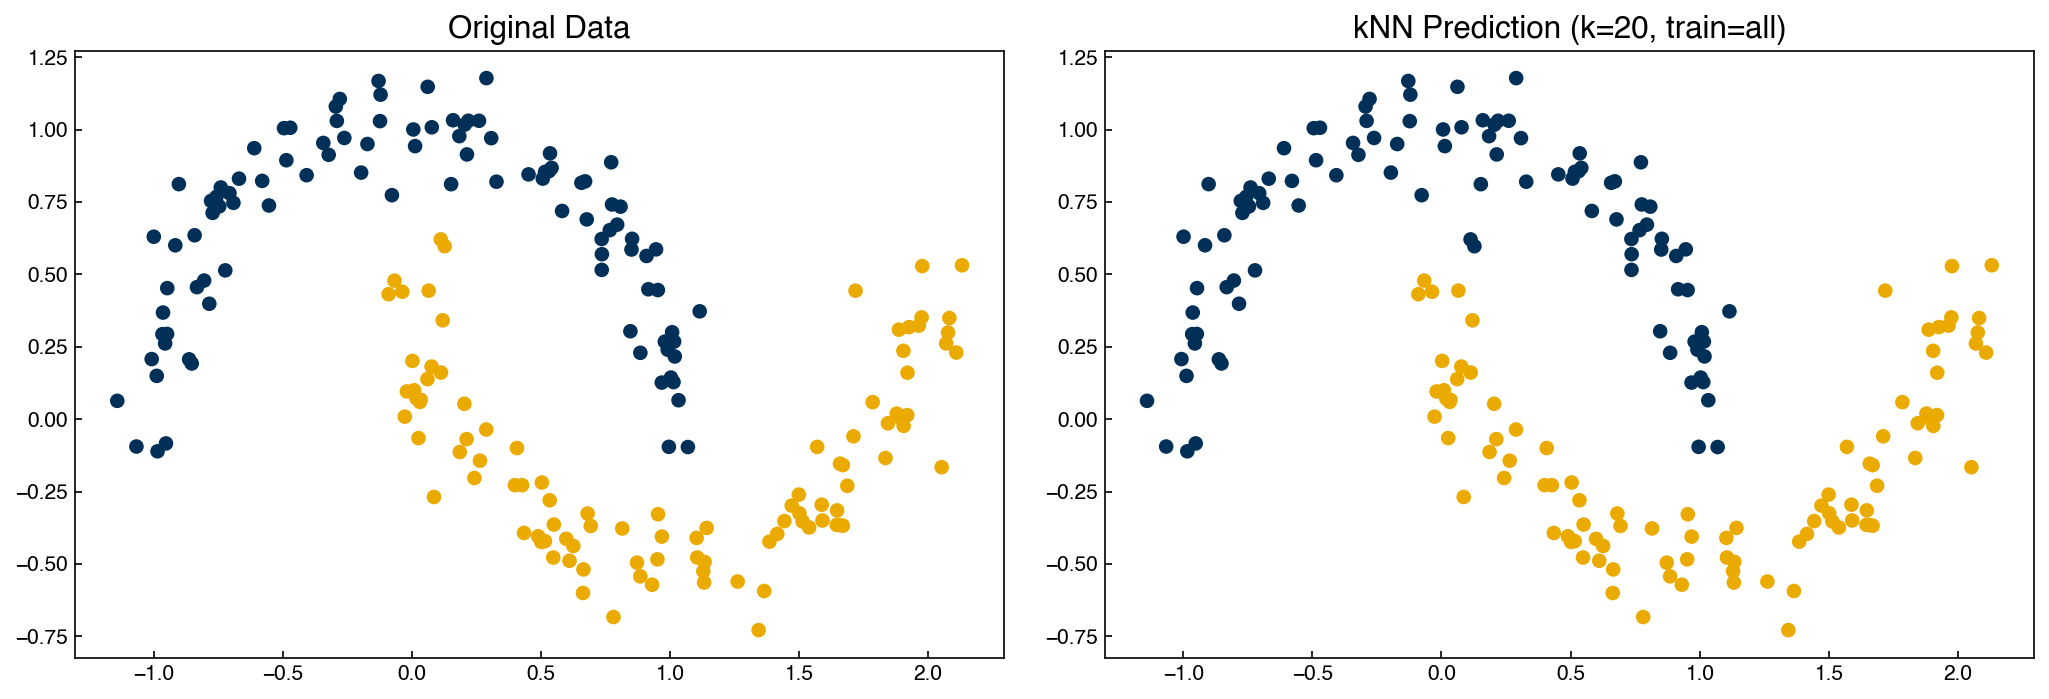

In [5]:
X, y = X_moons, y_moons

y_knn = kNN(X, 20, X, y)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(X[:, 0], X[:, 1], c=clrs[y])
axes[0].set_title('Original Data')
axes[1].scatter(X[:, 0], X[:, 1], c=clrs[y_knn])
axes[1].set_title('kNN Prediction (k=20, train=all)')
plt.tight_layout()
plt.show()

The model predicts every point correctly — but this is not a fair test because every
point is its own neighbor. Let's use a proper train/test split:

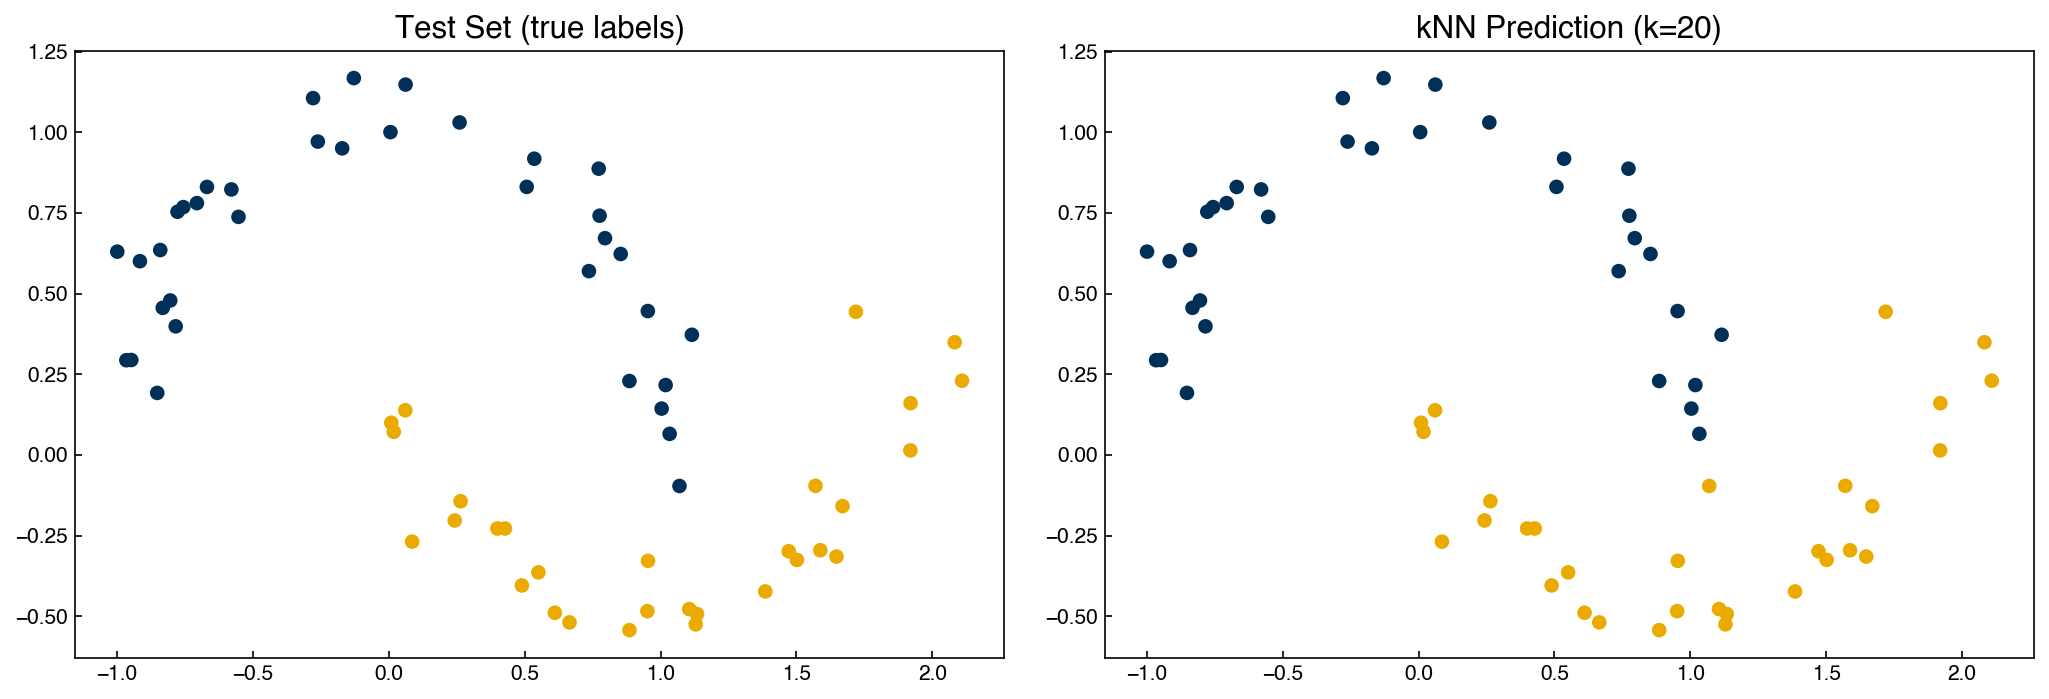

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=0)

y_knn = kNN(X_test, 20, X_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(X_test[:, 0], X_test[:, 1], c=clrs[y_test])
axes[0].set_title('Test Set (true labels)')
axes[1].scatter(X_test[:, 0], X_test[:, 1], c=clrs[y_knn])
axes[1].set_title('kNN Prediction (k=20)')
plt.tight_layout()
plt.show()

:::{note}
When kNN is trained on all the data and then predicts on the same data, every
test point finds itself as one of its own neighbors, so it will always be
classified correctly regardless of $k$. This inflated training accuracy is
meaningless — always evaluate on held-out data to get an honest picture of
generalization.
:::

kNN extends naturally to multi-class problems:

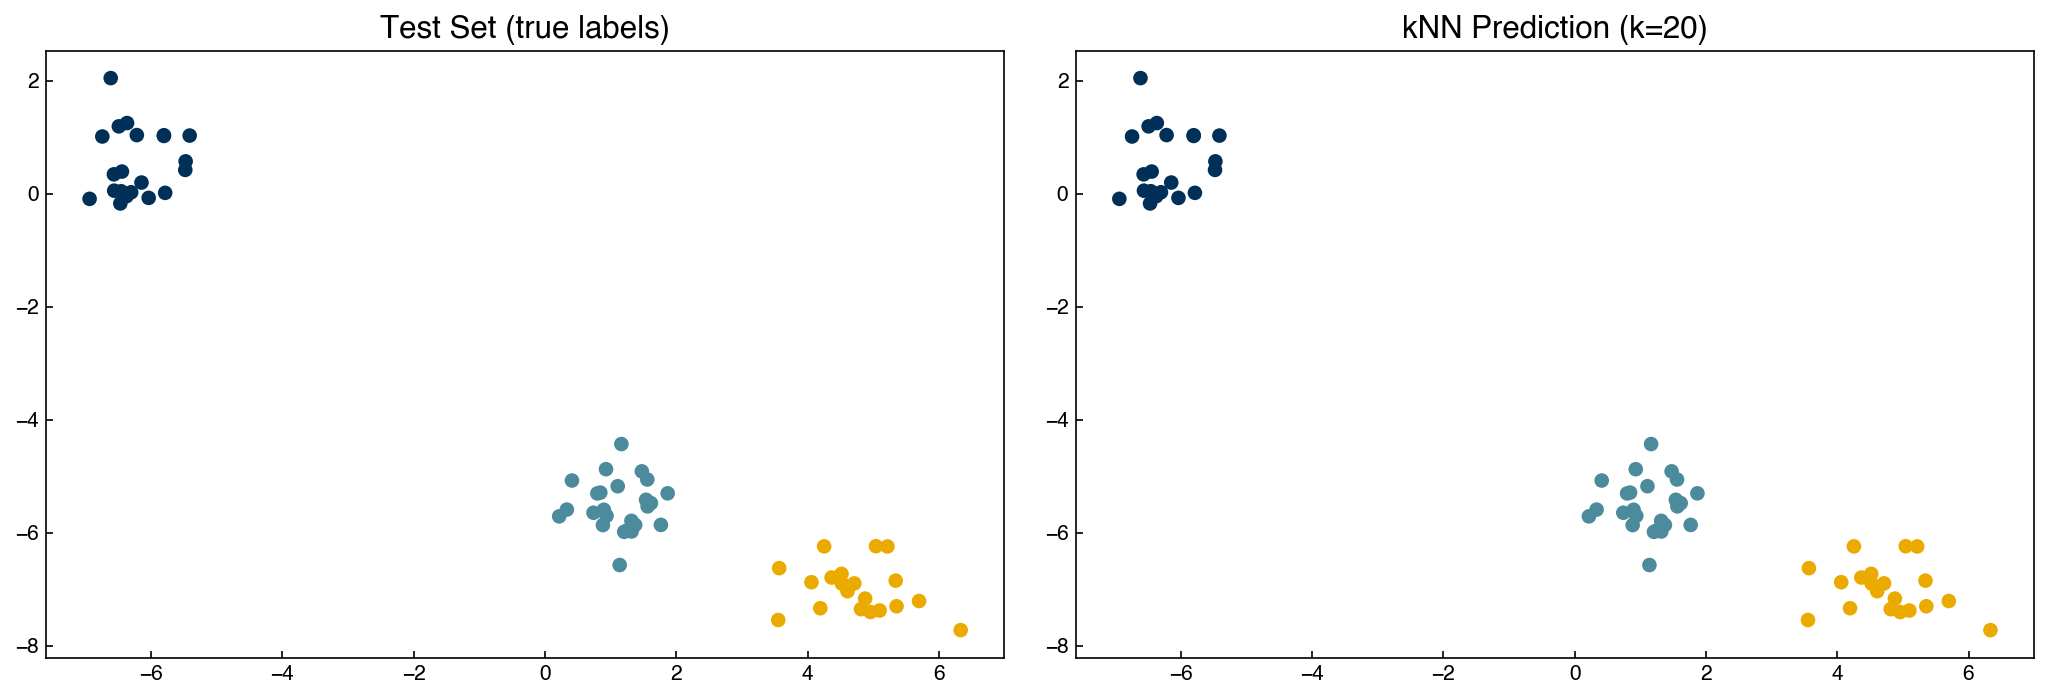

In [7]:
X, y = X_mc, y_mc

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=0)
y_knn = kNN(X_test, 20, X_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(X_test[:, 0], X_test[:, 1], c=clrs[y_test])
axes[0].set_title('Test Set (true labels)')
axes[1].scatter(X_test[:, 0], X_test[:, 1], c=clrs[y_knn])
axes[1].set_title('kNN Prediction (k=20)')
plt.tight_layout()
plt.show()

### Using scikit-learn

The scikit-learn `KNeighborsClassifier` is more efficient and enables decision-region
visualization:

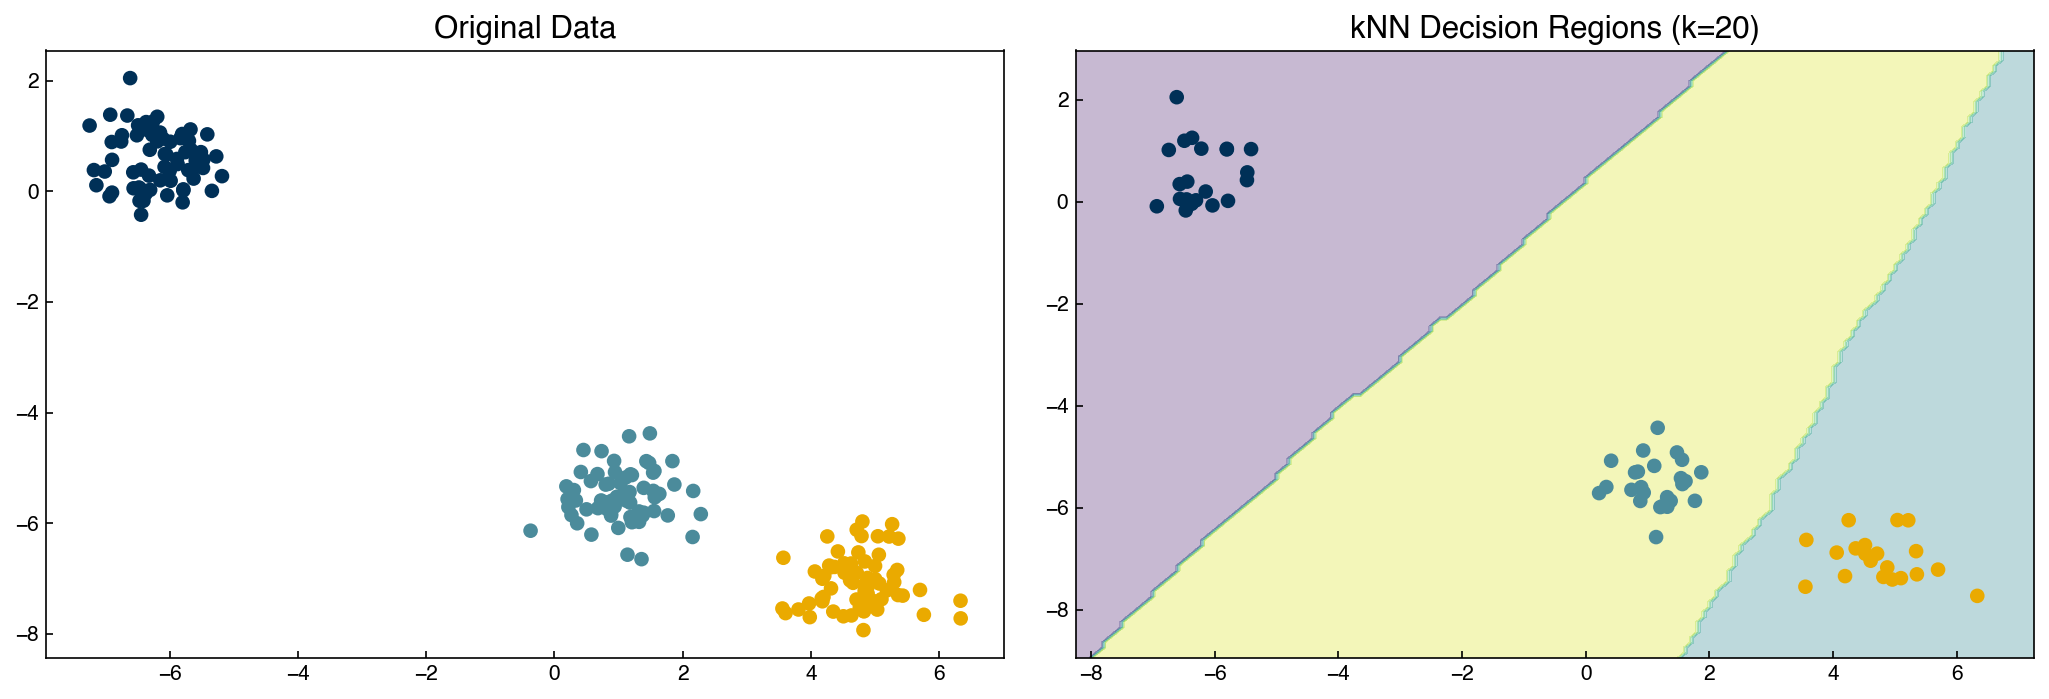

In [8]:
from sklearn.neighbors import KNeighborsClassifier

knn_sk = KNeighborsClassifier(n_neighbors=20)
knn_sk.fit(X_train, y_train)

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))
Z = knn_sk.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(X[:, 0], X[:, 1], c=clrs[y])
axes[0].set_title('Original Data')
axes[1].contourf(xx, yy, Z, alpha=0.3)
axes[1].scatter(X_test[:, 0], X_test[:, 1], c=clrs[knn_sk.predict(X_test)])
axes[1].set_title('kNN Decision Regions (k=20)')
plt.tight_layout()
plt.show()

### kNN Advantages and Disadvantages

| | |
|---|---|
| **Advantages** | Simple, intuitive, no training phase, highly non-linear boundaries, naturally multi-class |
| **Disadvantages** | Slow prediction for large training sets, poor scaling to high dimensions (curse of dimensionality), no interpretable model parameters |

The choice of $k$ directly controls the bias-variance trade-off. A small $k$ (e.g.,
$k=1$) gives a very flexible model that overfits to noise; a large $k$ smooths out
local structure and increases bias. In high-dimensional spaces, all points tend to
be roughly equidistant from one another — a phenomenon known as the **curse of
dimensionality** — which makes the "nearest" neighbors uninformative. For
high-dimensional chemical engineering applications (e.g., spectra, fingerprints),
dimensionality reduction or a different classifier is often preferable.

:::{exercise}
:label: ex-cls-knn-k

Using `KNeighborsClassifier` from scikit-learn and the moons dataset with a 70/30
train/test split (fix `random_state=0`), compute the test accuracy for
$k \in \{1, 5, 10, 20, 50, 100\}$. Plot accuracy vs. $k$.
Identify the value of $k$ that gives the best test accuracy and think about
why very small $k$ and very large $k$ both give poor results.
:::

---

## Naive Bayes Classification

Naive Bayes is a **generative** classifier: instead of learning a decision boundary
directly, it models the probability distribution of each class and then applies Bayes'
theorem.

The "naive" assumption is that the features are **conditionally independent** given the
class, and that each class follows a Gaussian distribution:

$$P(\vec{x} \mid y_i) \propto \exp\!\left(-\sum_j \frac{(x_j - \mu_{ij})^2}{2\sigma_{ij}^2}\right)$$

where $\mu_{ij}$ and $\sigma_{ij}$ are the mean and standard deviation of feature $j$
in class $i$, estimated directly from the training data.

Bayes' theorem then gives the posterior:

$$P(y_i \mid \vec{x}) = \frac{P(\vec{x} \mid y_i)\, P(y_i)}{P(\vec{x})}$$

The class with the highest posterior is the prediction.

### Visualizing the Generative Model

The code below visualizes the Gaussian distribution fit to each class. The contour
lines show constant-probability contours; a new point is classified by determining
which class distribution assigns it the highest probability.

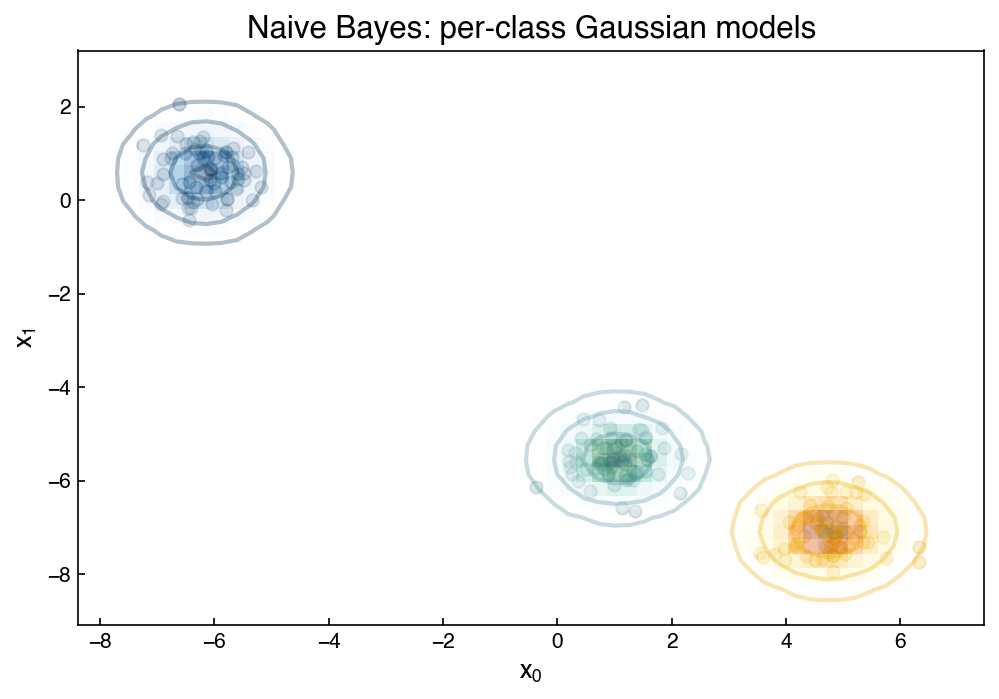

In [9]:
X, y = X_mc, y_mc
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=0)

fig, ax = plt.subplots(figsize=(7, 5))
ax.set_title('Naive Bayes: per-class Gaussian models')

xlim = (X[:, 0].min() - 1, X[:, 0].max() + 1)
ylim = (X[:, 1].min() - 1, X[:, 1].max() + 1)
xg = np.linspace(xlim[0], xlim[1], 60)
yg = np.linspace(ylim[0], ylim[1], 40)
xxg, yyg = np.meshgrid(xg, yg)
Xgrid = np.vstack([xxg.ravel(), yyg.ravel()]).T

cmaps = ['Blues', 'YlOrBr', 'BuGn']
for label, (color, cmap) in enumerate(zip(clrs[:3], cmaps)):
    mask = y == label
    ax.scatter(X[mask][:, 0], X[mask][:, 1], c=color, alpha=0.2)
    mu, std = X[mask].mean(0), X[mask].std(0)
    P = np.exp(-0.5 * ((Xgrid - mu) / std) ** 2).prod(1)
    Pm = np.ma.masked_array(P, P < 0.03)
    ax.pcolormesh(xxg, yyg, Pm.reshape(xxg.shape), alpha=0.4, cmap=cmap, shading='auto')
    ax.contour(xxg, yyg, P.reshape(xxg.shape),
               levels=[0.01, 0.1, 0.5, 0.9], colors=color, alpha=0.3)

ax.set_xlabel('$x_0$')
ax.set_ylabel('$x_1$')
plt.tight_layout()
plt.show()

### Using scikit-learn

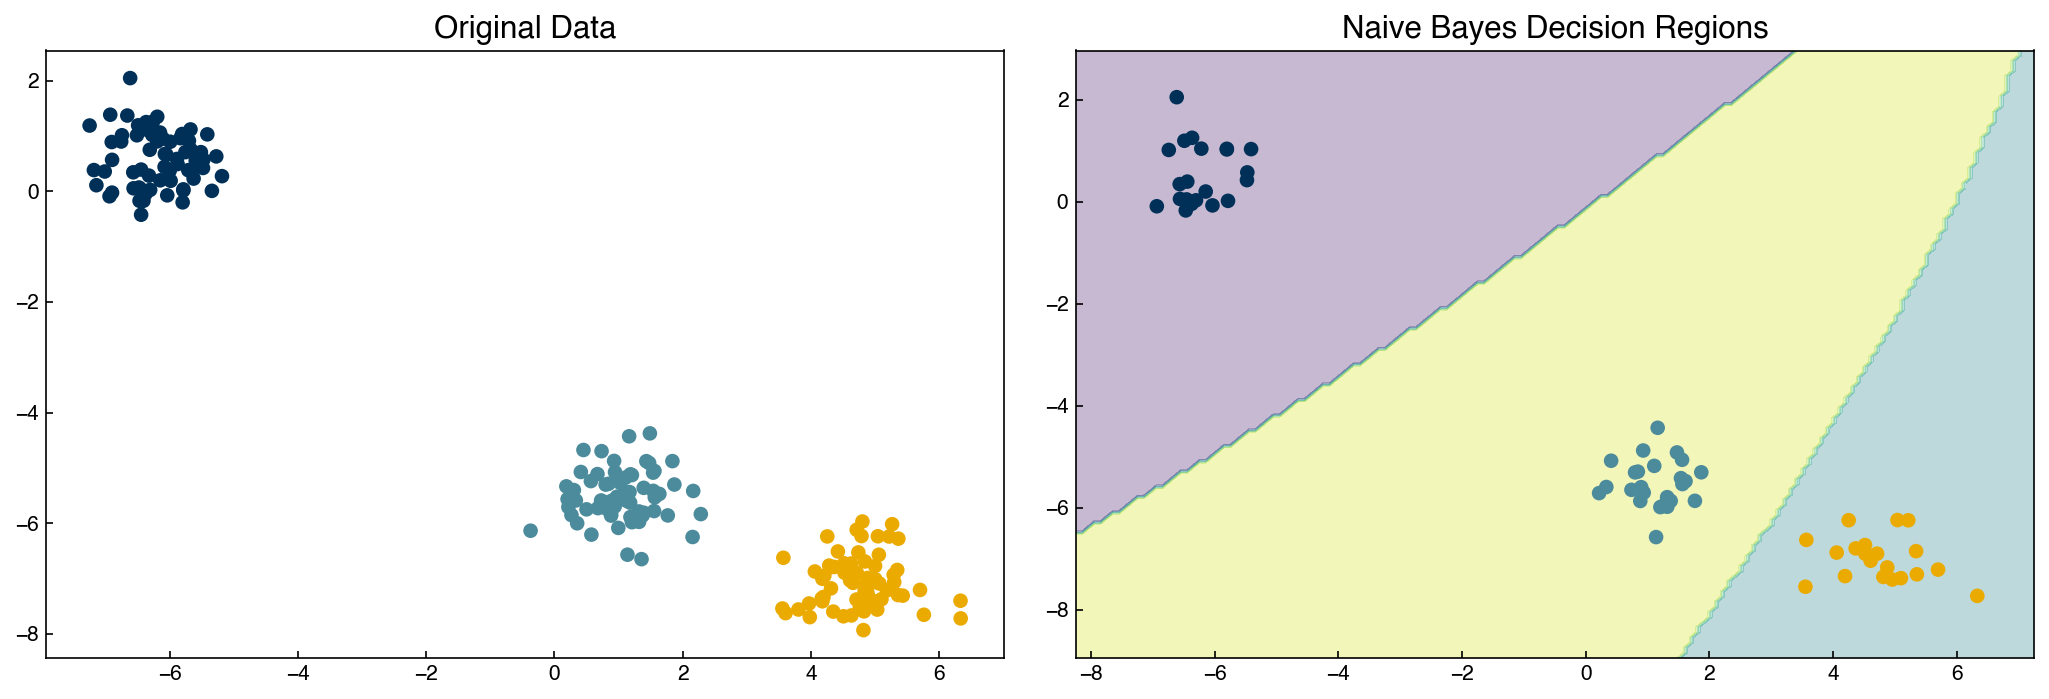

In [10]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx_nb, yy_nb = np.meshgrid(np.arange(x_min, x_max, 0.1),
                            np.arange(y_min, y_max, 0.1))
Z_nb = nb.predict(np.c_[xx_nb.ravel(), yy_nb.ravel()]).reshape(xx_nb.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(X[:, 0], X[:, 1], c=clrs[y])
axes[0].set_title('Original Data')
axes[1].contourf(xx_nb, yy_nb, Z_nb, alpha=0.3)
axes[1].scatter(X_test[:, 0], X_test[:, 1], c=clrs[nb.predict(X_test)])
axes[1].set_title('Naive Bayes Decision Regions')
plt.tight_layout()
plt.show()

:::{note}
Naive Bayes is a **parametric** model. The parameters are the per-class means
$\mu_{ij}$ and standard deviations $\sigma_{ij}$. The number of parameters grows
with the number of features but not with the number of training samples, which is
the defining property of a parametric model.

Because it models class distributions explicitly, Naive Bayes has a natural advantage
for anomaly detection: a point that falls in a low-probability region of *all* class
distributions can be flagged as an outlier, something discriminative models cannot do
directly.
:::

Naive Bayes works well for linearly (or near-linearly) separable classes that are
approximately Gaussian, but will struggle on highly non-linear datasets like moons or
circles where the class-conditional Gaussians overlap badly.

### Naive Bayes Advantages and Disadvantages

| | |
|---|---|
| **Advantages** | Extremely fast to train, difficult to overfit, gives probabilistic predictions, natural class-imbalance correction via prior $P(y_i)$ |
| **Disadvantages** | Decision boundaries are quadratic (elliptical), independence assumption rarely holds exactly, poor on highly non-linear data |

:::{exercise}
:label: ex-cls-nb-circles

Apply `GaussianNB` to the **circles** dataset (`X_circles`, `y_circles`) using a
70/30 train/test split. Plot the decision regions. Compute and print the test
accuracy. Think about why you expect Naive Bayes to perform poorly here,
referencing the Gaussian independence assumption.
:::

---

## Decision Trees

A decision tree is a **discriminative** classifier that partitions the feature space
with a series of axis-aligned cuts. At each internal node the tree asks a yes/no
question about one feature (e.g., "is $x_0 > 2.5$?") and routes the sample left or
right accordingly. Leaves contain class predictions.

The splitting criterion is chosen to maximize **information gain** — reducing the
impurity of the resulting subsets, measured by the Gini index or Shannon entropy.
The process is recursive: after each split, the algorithm repeats on the two subsets
until a stopping criterion is reached (e.g., all samples in a leaf belong to the same
class, or a maximum depth is hit).

Decision trees are highly prone to **overfitting** because the tree can always grow
until it perfectly memorizes the training data. The **random forest** addresses this
by training an ensemble of trees on bootstrap samples of the data and averaging their
predictions, similar to the bootstrapping techniques seen in the regression chapters.

### Demonstration: Decision Tree on Toy Datasets

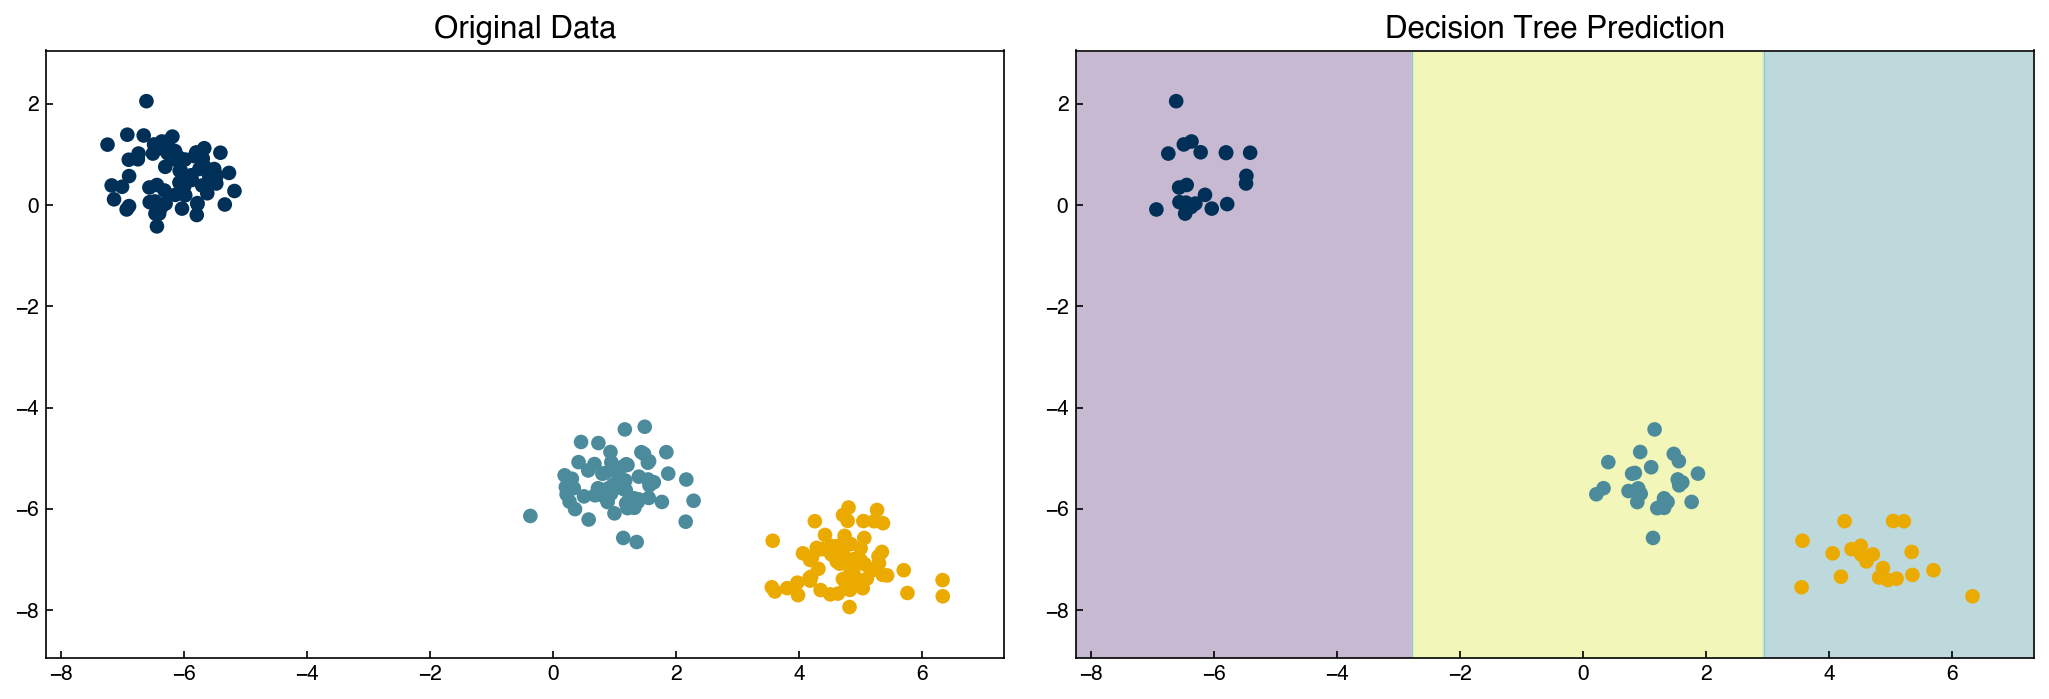

In [11]:
from sklearn.tree import DecisionTreeClassifier

X, y = X_mc, y_mc
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=0)

tree = DecisionTreeClassifier(random_state=0)
tree.fit(X_train, y_train)

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx_t, yy_t = np.meshgrid(np.arange(x_min, x_max, 0.05),
                          np.arange(y_min, y_max, 0.05))
Z_tree = tree.predict(np.c_[xx_t.ravel(), yy_t.ravel()]).reshape(xx_t.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(X[:, 0], X[:, 1], c=clrs[y])
axes[0].set_title('Original Data')
axes[1].contourf(xx_t, yy_t, Z_tree, alpha=0.3)
axes[1].scatter(X_test[:, 0], X_test[:, 1], c=clrs[tree.predict(X_test)])
axes[1].set_title('Decision Tree Prediction')
for ax in axes:
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
plt.tight_layout()
plt.show()

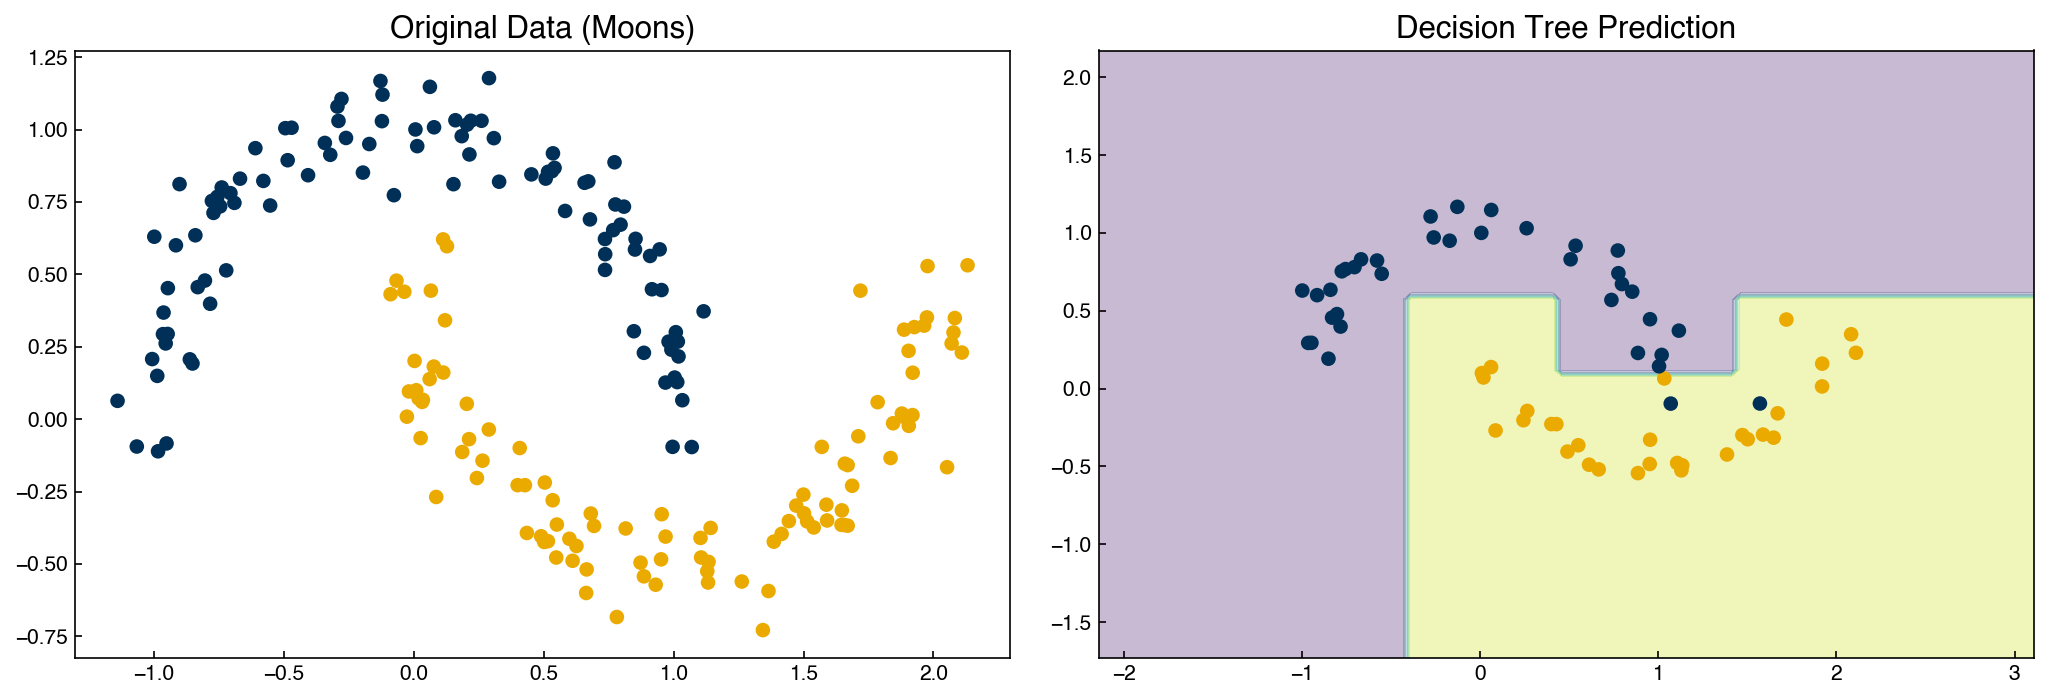

In [12]:
X, y = X_moons, y_moons
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=0)

tree.fit(X_train, y_train)

x_min2, x_max2 = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min2, y_max2 = X[:, 1].min() - 1, X[:, 1].max() + 1
xx_m, yy_m = np.meshgrid(np.arange(x_min2, x_max2, 0.05),
                          np.arange(y_min2, y_max2, 0.05))
Z_moons = tree.predict(np.c_[xx_m.ravel(), yy_m.ravel()]).reshape(xx_m.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(X[:, 0], X[:, 1], c=clrs[y])
axes[0].set_title('Original Data (Moons)')
axes[1].contourf(xx_m, yy_m, Z_moons, alpha=0.3)
axes[1].scatter(X_test[:, 0], X_test[:, 1], c=clrs[tree.predict(X_test)])
axes[1].set_title('Decision Tree Prediction')
plt.tight_layout()
plt.show()

### Visualizing the Tree Structure

Unlike kNN, a decision tree produces an interpretable model we can inspect directly:

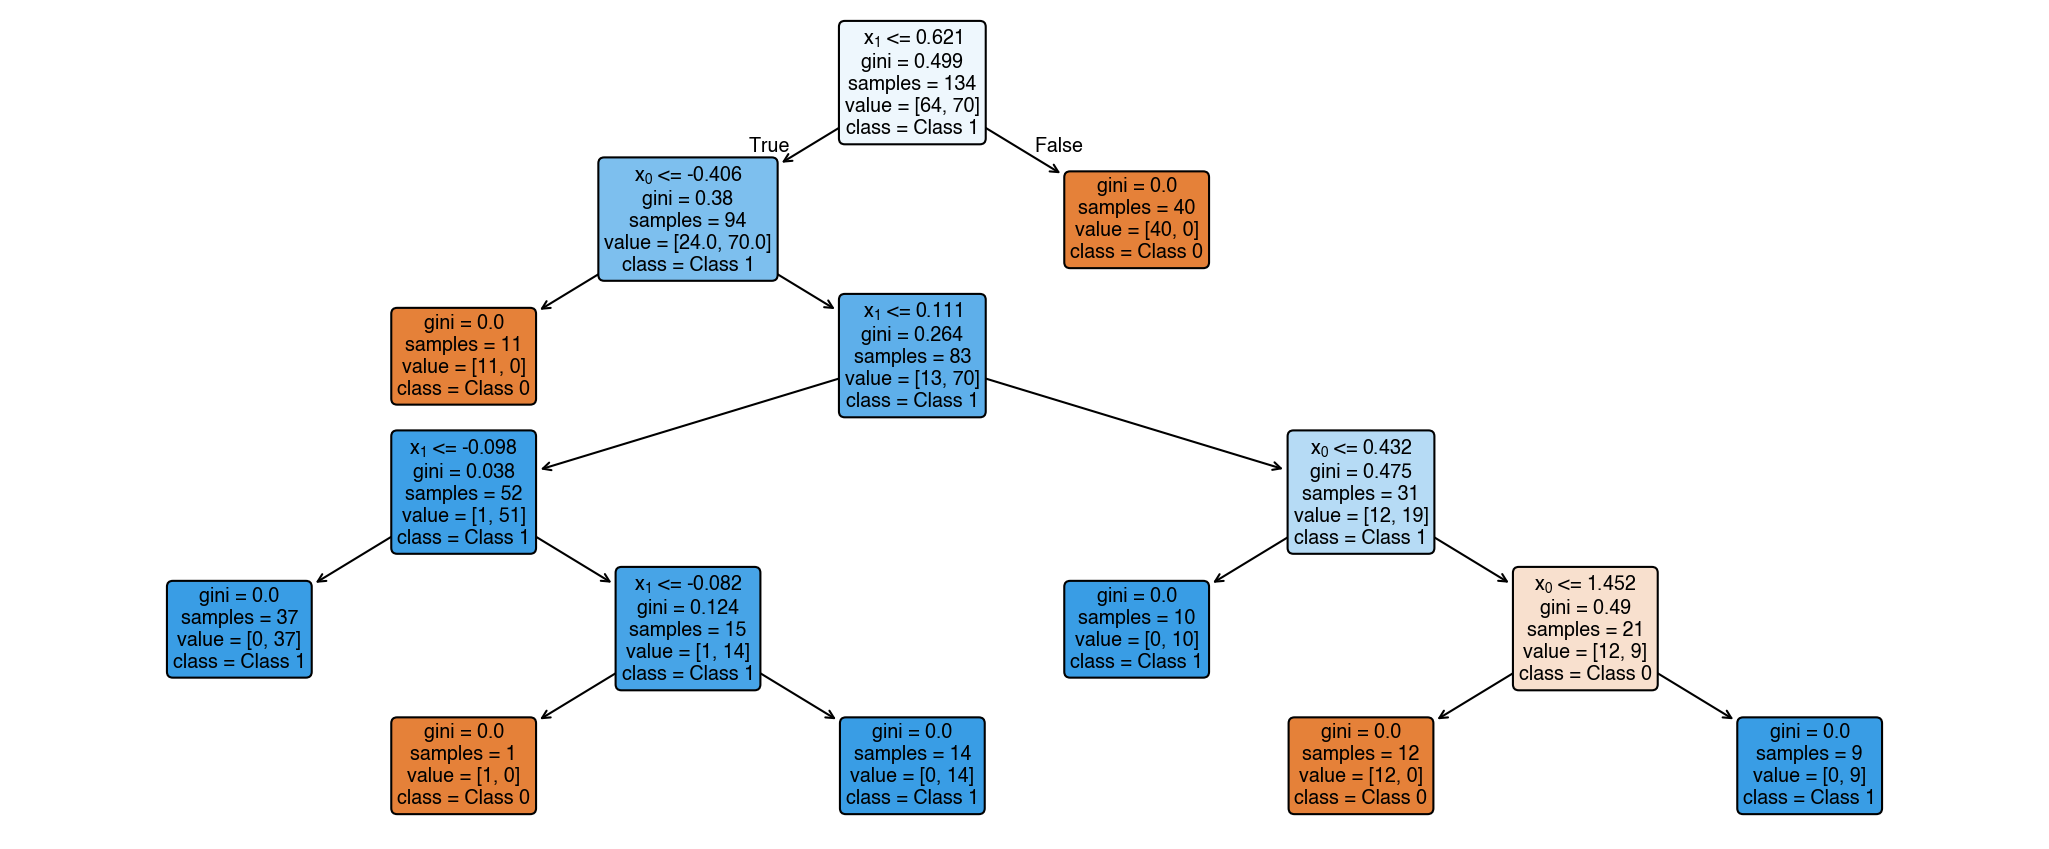

In [13]:
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(14, 6))
plot_tree(tree, filled=True, rounded=True, ax=ax,
          class_names=['Class 0', 'Class 1'],
          feature_names=['$x_0$', '$x_1$'])
plt.tight_layout()
plt.show()

Each node shows the splitting rule, the Gini impurity, the sample count, and the
class breakdown. Following a path from root to leaf traces the sequence of decisions
applied to classify a new point.

:::{note}
An unconstrained decision tree will grow until every leaf contains a single training
sample, achieving perfect training accuracy but poor generalization. Regularization
strategies include limiting `max_depth`, requiring a minimum number of samples per
leaf (`min_samples_leaf`), or using a random forest ensemble. The `max_depth`
hyperparameter has the most direct effect on the bias-variance trade-off.
:::

### Random Forests

In practice, a single decision tree is rarely used directly because its high variance
makes it unreliable. The **random forest** algorithm trains many trees, each on a
bootstrap sample of the training data and using only a random subset of features at
each split. Predictions are made by majority vote across the ensemble. This reduces
variance dramatically while preserving the non-linear expressiveness of individual
trees.

Random forests also provide a useful **feature importance** score: features that appear
near the root of many trees (where they reduce impurity the most) are ranked as more
important. This can be a valuable tool in chemical engineering applications where
identifying which process variables or molecular descriptors drive a classification
outcome matters as much as predictive accuracy.

### Decision Tree Advantages and Disadvantages

| | |
|---|---|
| **Advantages** | Highly interpretable, handles non-linear boundaries, works natively with categorical features, fast to train |
| **Disadvantages** | Very prone to overfitting without constraints, decision boundaries are axis-aligned (jagged), sensitive to small changes in training data |

:::{exercise}
:label: ex-cls-tree-depth

Using the **moons** dataset with a 70/30 train/test split (`random_state=0`), train
`DecisionTreeClassifier` models with `max_depth` set to each value in
`[1, 2, 3, 5, 10, None]`. For each depth, compute both the training accuracy and
the test accuracy. Plot both curves on the same axes with depth on the x-axis.
Identify the depth that best balances bias and variance.
:::

---

## Summary

- **k-Nearest Neighbors** is a lazy, instance-based learner: no explicit training,
  prediction by majority vote of the $k$ closest training points. Key
  hyperparameters are $k$ and the distance metric. Works well in low dimensions
  but is slow at prediction time and degrades in high dimensions.

- **Naive Bayes** is a generative, parametric model that fits a Gaussian per class
  and applies Bayes' theorem. Fast, hard to overfit, gives calibrated probabilities,
  and handles class imbalance via the prior. Assumes conditional independence of
  features and Gaussian class distributions, limiting it to roughly linear or
  elliptical boundaries.

- **Decision Trees** recursively partition feature space with axis-aligned splits
  chosen to maximize information gain. Highly interpretable and non-linear, but
  strongly prone to overfitting. Random forests mitigate this by averaging over
  bootstrap ensembles of trees.

- In practice, model selection requires comparing performance, training time, and
  prediction time across algorithms — there is no universally best classifier.

## Additional Reading

- Hastie, Tibshirani & Friedman, *The Elements of Statistical Learning*, Ch. 13
  (kNN), Ch. 6.6 (Naive Bayes), Ch. 9 (Decision Trees) —
  [free PDF](https://hastie.su.domains/ElemStatLearn/)
- scikit-learn User Guide:
  [Nearest Neighbors](https://scikit-learn.org/stable/modules/neighbors.html),
  [Naive Bayes](https://scikit-learn.org/stable/modules/naive_bayes.html),
  [Decision Trees](https://scikit-learn.org/stable/modules/tree.html)
- Breiman (2001), "Random Forests," *Machine Learning* 45, 5-32 — the foundational
  paper for random forest ensembles